# 01 Environment and Data

**Phase 1 of the project.** Before training any agent I need to know exactly what it will see, what its actions do, and what "good" means. This notebook covers:

1. **Data**: Binance BTC/USDT hourly candles, the default features, and my dev-train / validation / eval split.
2. **Environment mechanics**: observation, timing of the reward, fees, borrow interest, randomness, and the traps I found in `gym-trading-env` 0.3.5.
3. **Benchmarks**: simple strategies that define the bar my agent has to clear.

All logic lives in the `rl_trading` package; this notebook imports it and tells the story.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from gym_trading_env.utils.portfolio import TargetPortfolio

from rl_trading.data import load_raw_data, add_default_features, split_data
from rl_trading.envs import (make_env, make_validation_envs, prepare_env_data,
                             POSITIONS, TRADING_FEES, BORROW_INTEREST_RATE)
from rl_trading.evaluate import ConstantAgent, RandomAgent, evaluate, validate

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.width", 160)

In [2]:
# Chart style shared by the figures of this notebook
SURF, INK, INK2, GRID, NEUTRAL = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#8a8984"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # fixed categorical order

def style_axis(ax, title):
    ax.set_facecolor(SURF)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.set_title(title, loc="left", color=INK, fontsize=11)

## 1. Data

Hourly BTC/USDT klines from the public Binance API, downloaded with the code of the instruction notebook: 7 extra days before the training year so the rolling features are defined from the first training hour on. `validate_hourly` raises an error if any hour is missing, duplicated or invalid (e.g. a high below the close).

| Split | Period (UTC, end exclusive) | Use |
|---|---|---|
| Dev-train | 2025-08-17 to 2026-06-17 | training during development |
| Validation | 2026-06-17 to 2026-08-17 | **all** model selection |
| Eval (fixed by the course) | 2026-08-17 to 2026-09-17 | touched once for the baseline, once for the final model |

The eval month already lies in the past, so tuning on it would be data snooping. I do not plot or inspect its prices until the final model is frozen.

In [3]:
raw = load_raw_data(ROOT / "data")
df = add_default_features(raw)
splits = split_data(df)
dev, val = splits["dev_train"], splits["val"]

Downloaded data: 9,672 candles, 2025-08-10 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 7,296 candles, 2025-08-17 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


In [4]:
def split_summary(d):
    log_ret = np.log(d["close"]).diff().dropna()
    return {
        "candles": len(d),
        "first close": round(d["close"].iloc[0]),
        "last close": round(d["close"].iloc[-1]),
        "buy & hold": f"{d['close'].iloc[-1] / d['close'].iloc[0] - 1:+.2%}",
        "hourly std": f"{log_ret.std():.2%}",
        "median |hourly move|": f"{log_ret.abs().median():.2%}",
        "lag-1 autocorr": round(log_ret.autocorr(1), 3),
    }

pd.DataFrame({"dev_train": split_summary(dev), "val": split_summary(val)}).T

,candles,first close,last close,buy & hold,hourly std,median |hourly move|,lag-1 autocorr
dev_train,7296,117255,65675,-43.99%,0.47%,0.20%,0.006
val,1464,65700,62900,-4.26%,0.38%,0.16%,-0.05


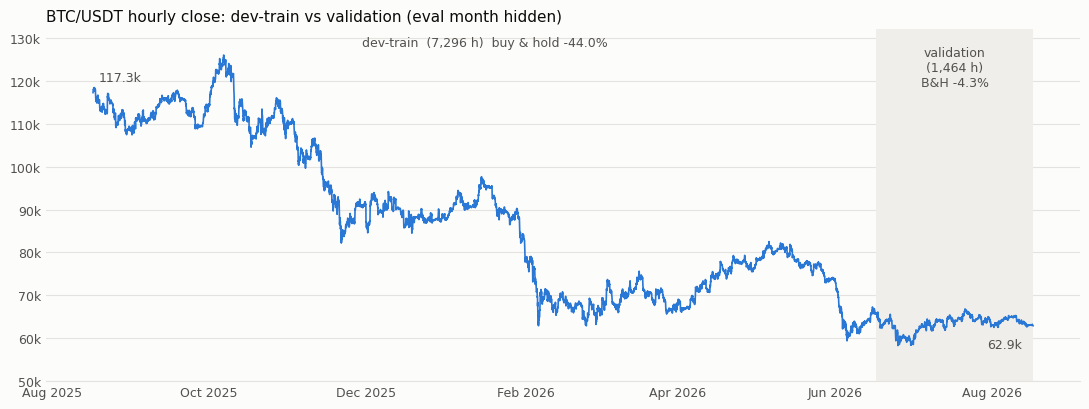

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2), facecolor=SURF)
style_axis(ax, "BTC/USDT hourly close: dev-train vs validation (eval month hidden)")
dev_close, val_close = dev["close"].tz_localize(None), val["close"].tz_localize(None)
ax.axvspan(val_close.index[0], val_close.index[-1], color="#efeeea", lw=0)
ax.plot(dev_close, color=SERIES[0], lw=1.2)
ax.plot(val_close, color=SERIES[0], lw=1.2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
label = dict(fontsize=9, color=INK2)
ax.text(dev_close.index[len(dev_close) // 2], 128_000, "dev-train  (7,296 h)  buy & hold -44.0%", ha="center", **label)
ax.text(val_close.index[len(val_close) // 2], 128_000, "validation\n(1,464 h)\nB&H -4.3%", ha="center", va="top", **label)
ax.annotate(f"{dev_close.iloc[0] / 1000:.1f}k", (dev_close.index[0], dev_close.iloc[0]), xytext=(4, 8), textcoords="offset points", **label)
ax.annotate(f"{val_close.iloc[-1] / 1000:.1f}k", (val_close.index[-1], val_close.iloc[-1]), xytext=(-8, -16), textcoords="offset points", ha="right", **label)
ax.set_ylim(50_000, 132_000)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_price_dev_val.png", dpi=150, facecolor=SURF)
plt.show()

**Observations.**
- Dev-train is a strong bear market (-44%), validation moves sideways (-4%). An agent trained here may simply learn to short.
- Hourly moves are small (median about 0.2%) and almost uncorrelated from one hour to the next: close to a random walk. Any learnable edge will be small, so results must be compared across several seeds and against benchmarks.

### Default features

Every column whose name contains `feature` becomes part of the observation. The instruction notebook defines five, all causal (they use only candles up to the current one):

| Feature | Formula | Meaning |
|---|---|---|
| `feature_close` | close_t / close_(t-1) - 1 | return of the last hour |
| `feature_open` | open / close | direction of the candle |
| `feature_high` | high / close | how far above the close the price went |
| `feature_low` | low / close | how far below the close the price went |
| `feature_volume` | volume / max(volume, last 168 h) | activity relative to the past week |

In [6]:
features = [c for c in df.columns if "feature" in c]
dev[features].describe().loc[["mean", "std", "min", "max"]].T

,mean,std,min,max
feature_close,-0.000068,0.004719,-0.037185,0.034728
feature_open,1.000091,0.004725,0.966437,1.038621
feature_high,1.003200,0.003559,1.000000,1.039276
feature_low,0.996750,0.003645,0.899060,1.000000
feature_volume,0.180194,0.163322,0.009671,1.000000


In [7]:
dev[features].corr().round(2)

,feature_close,feature_open,feature_high,feature_low,feature_volume
feature_close,1.00,-1.00,-0.66,-0.55,-0.06
feature_open,-1.00,1.00,0.66,0.54,0.07
feature_high,-0.66,0.66,1.00,0.00,0.46
feature_low,-0.55,0.54,0.00,1.00,-0.44
feature_volume,-0.06,0.07,0.46,-0.44,1.00


In [8]:
# BTC trades 24/7: every hour opens at the previous close
gap = (dev["open"] / dev["close"].shift(1) - 1).dropna()
print(f"|open_t / close_(t-1) - 1|: median {gap.abs().median():.1e}, max {gap.abs().max():.1e}")

|open_t / close_(t-1) - 1|: median 0.0e+00, max 7.5e-05


**Observations.**
- `feature_open` is a pure duplicate: since open_t = close_(t-1), it equals 1 / (1 + `feature_close`) (correlation -1.00). Only four of the five features carry distinct information.
- open, high and low ratios sit around 1.000 with a standard deviation of about 0.004: an almost constant input for a neural network. Input normalisation is a candidate improvement for Phase 4.
- The 168-hour volume window uses exactly the 7 warm-up days. A longer lookback would need an earlier download start.

## 2. Environment mechanics

The agent chooses an index into `POSITIONS = [-1, 0, 0.5, 1, 2]`. A position is the share of the portfolio bet on BTC: -1 is a full short, 0 is out of the market, 2 is long with 2x leverage. Portfolio change ≈ position x BTC change.

### Observation

In [9]:
env = make_env(val.iloc[:50])
obs, info = env.reset()
print("observation shape:", obs.shape, obs.dtype)
print("columns:", env.unwrapped._features_columns)
print("values:", np.round(obs, 5))

observation shape: (7,) float32
columns: ['feature_close', 'feature_open', 'feature_high', 'feature_low', 'feature_volume', 'dynamic_feature__0', 'dynamic_feature__1']
values: [3.80000e-04 9.99620e-01 1.00225e+00 9.99620e-01 1.12450e-01 0.00000e+00
 0.00000e+00]


Five market features plus two dynamic features added by the environment: the last position taken and the real position (which drifts with the price while a position is held).

### Timing of the reward

`step(a)` trades at the close of the current hour, then moves one hour forward. The reward is the log return of the portfolio value over that hour, after fees: r_t = ln(V_(t+1) / V_t). Features of hour t are therefore legitimate inputs for the action at hour t.

In [10]:
closes = val["close"].to_numpy()
market_log_return = np.log(closes[1] / closes[0])

env = make_env(val.iloc[:50], initial_position=1)
env.reset()
_, reward_hold, *_ = env.step(POSITIONS.index(1))          # stay long: no trade, no fee

env = make_env(val.iloc[:50], initial_position=0)
env.reset()
_, reward_buy, *_ = env.step(POSITIONS.index(1))           # buy at close_0: pays the fee

print(f"log(close_1 / close_0) = {market_log_return:.6f}")
print(f"reward, stay long      = {reward_hold:.6f}")
print(f"reward, flat -> long   = {reward_buy:.6f}   (difference {market_log_return - reward_buy:.6f} = 0.01% fee)")

log(close_1 / close_0) = 0.003646
reward, stay long      = 0.003646
reward, flat -> long   = 0.003546   (difference 0.000100 = 0.01% fee)


### Trap: the observation is a view into the environment's memory

`reset` and `step` return a row of an internal numpy array, not a copy. When a later episode visits the same hour, the environment overwrites that row's position features. If raw observations are stored in a replay buffer, old transitions silently change. Below, episode 1 is always short, episode 2 always 2x long on the same hours.

In [11]:
env = make_env(val.iloc[:20], initial_position=0)
obs, _ = env.reset()
stored_raw, stored_copy = [obs], [np.array(obs, copy=True)]
done = truncated = False
while not (done or truncated):                      # episode 1: always short
    obs, _, done, truncated, _ = env.step(POSITIONS.index(-1))
    stored_raw.append(obs)
    stored_copy.append(np.array(obs, copy=True))
print("position features of stored state 5 after episode 1:", stored_raw[5][-2:])

env.reset()
done = truncated = False
while not (done or truncated):                      # episode 2: always 2x long
    _, _, done, truncated, _ = env.step(POSITIONS.index(2))
print("same raw stored state after episode 2:              ", stored_raw[5][-2:], "<- changed")
print("copied stored state after episode 2:                ", stored_copy[5][-2:], "<- correct")

position features of stored state 5 after episode 1: [-1.        -1.0041639]
same raw stored state after episode 2:               [2.        1.9958739] <- changed
copied stored state after episode 2:                 [-1.        -1.0041639] <- correct


**Consequence:** my replay buffer stores `np.array(obs, copy=True)` for both s and s'.

A second trap: importing the environment runs `warnings.filterwarnings("error")`, so any harmless library warning would crash the program. `make_env` restores normal warning behaviour after creating the environment.

### Fees

The fee is 0.01% of the traded amount, so a position change costs 0.01% x |new - old| of the portfolio. Bigger jumps cost more; staying put is free.

In [12]:
fee_table = pd.DataFrame(index=pd.Index(POSITIONS, name="from"), columns=pd.Index(POSITIONS, name="to"), dtype=float)
for p_from in POSITIONS:
    for p_to in POSITIONS:
        portfolio = TargetPortfolio(position=p_from, value=1000.0, price=100.0)
        portfolio.trade_to_position(p_to, price=100.0, trading_fees=TRADING_FEES)
        fee_table.loc[p_from, p_to] = 1 - portfolio.valorisation(100.0) / 1000.0
(fee_table * 100).round(4).astype(str) + "%"

to,-1.0,0.0,0.5,1.0,2.0
from,,,,,
-1.0,0.0%,0.01%,0.015%,0.02%,0.03%
0.0,0.01%,0.0%,0.005%,0.01%,0.02%
0.5,0.015%,0.005%,0.0%,0.005%,0.015%
1.0,0.02%,0.01%,0.005%,0.0%,0.01%
2.0,0.03%,0.02%,0.015%,0.01%,0.0%


A random agent picks a new position every hour. Averaged over the 25 equally likely (old, new) pairs, the jump is 28 / 25 = 1.12 times the portfolio, so over one eval-length episode of 743 steps the fees alone cost about 743 x 1.12 x 0.01% ≈ 8.3%:

In [13]:
val_envs = make_validation_envs(val)
_, details = validate(RandomAgent(len(POSITIONS), seed=0), {"val_w1": val_envs["val_w1"]})
print(f"random agent, 743 steps: {details['val_w1']['n_changes'].mean():.0f} position changes, "
      f"fees about {details['val_w1']['fees_approx'].mean():.2%} of the portfolio")

random agent, 743 steps: 595 position changes, fees about 8.44% of the portfolio


### Borrow interest is effectively not charged

The course sets a borrow rate of 0.0003% per hour for short and leveraged positions. In `gym-trading-env` 0.3.5 the interest is overwritten every step instead of accumulated, so only a single hour of interest is ever deducted. Holding a position over all of dev-train, with and without the borrow rate:

In [14]:
def hold_return(frame, position, borrow_rate):
    # Hold one position for the whole frame without fees (built directly to vary the borrow rate)
    env = gym.make("TradingEnv", df=prepare_env_data(frame), positions=POSITIONS, trading_fees=0.0,
                   borrow_interest_rate=borrow_rate, initial_position=position, verbose=0)
    warnings.simplefilter("default")
    env.reset()
    for _ in range(len(frame) - 1):
        *_, info = env.step(POSITIONS.index(position))
    return info["portfolio_valuation"] / 1000 - 1

steps = len(dev) - 1
for position in [2, -1]:
    with_rate, without_rate = hold_return(dev, position, BORROW_INTEREST_RATE), hold_return(dev, position, 0.0)
    print(f"hold {position:>2}: with borrow rate {with_rate:+.4%}, without {without_rate:+.4%}, "
          f"difference {with_rate - without_rate:+.5%} (accumulating interest: about {-steps * BORROW_INTEREST_RATE:+.2%})")

hold  2: with borrow rate -87.9797%, without -87.9794%, difference -0.00030% (accumulating interest: about -2.19%)
hold -1: with borrow rate +43.9895%, without +43.9897%, difference -0.00017% (accumulating interest: about -2.19%)


**Consequences.**
- Shorting and leverage cost only fees; their real cost is risk.
- Holding a position does not rebalance: the env only trades when the target position changes, so a held 2x position drifts with the price. Holding 2x through dev-train ends at -88%, and a held 2x position goes bankrupt after a -50% move since entry (a held short after +100%).

### Randomness

Each reset draws a random initial position (and, with `max_episode_duration`, a random start hour) from the **global** `np.random`. The `seed` argument of `env.reset` does not control it; `np.random.seed` does.

In [15]:
env = make_env(val.iloc[:50])
print("env.reset(seed=0) x 6:          ", [float(env.reset(seed=0)[1]["position"]) for _ in range(6)])
seeded = []
for _ in range(6):
    np.random.seed(0)
    seeded.append(float(env.reset()[1]["position"]))
print("np.random.seed(0) before reset: ", seeded)

env = make_env(dev, max_episode_duration=168)
lengths = []
for _ in range(20):
    env.reset()
    n, done, truncated = 0, False, False
    while not (done or truncated):
        _, _, done, truncated, _ = env.step(0)
        n += 1
    lengths.append(n)
print("max_episode_duration=168 -> steps per episode:", set(lengths))

env.reset(seed=0) x 6:           [1.0, 0.0, 2.0, 0.5, 0.5, 2.0]
np.random.seed(0) before reset:  [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
max_episode_duration=168 -> steps per episode: {167}


## 3. Benchmarks: what does "good" mean?

Simple strategies that ignore the market data, evaluated with the same protocol as the course's `evaluate_agent`: 10 episodes, each starting from a random initial position (seeded, so every strategy faces the same initial positions).

Validation is two months long while an eval episode covers one month, so I also evaluate on two eval-length windows of 744 candles: `val_w1` (first month) and `val_w2` (last month, overlapping `val_w1` by 24 hours).

In [16]:
benchmarks = {
    "random": lambda: RandomAgent(len(POSITIONS), seed=0),
    "always flat (0)": lambda: ConstantAgent(POSITIONS, 0),
    "always 0.5": lambda: ConstantAgent(POSITIONS, 0.5),
    "buy and hold (1)": lambda: ConstantAgent(POSITIONS, 1),
    "always 2x (2)": lambda: ConstantAgent(POSITIONS, 2),
    "always short (-1)": lambda: ConstantAgent(POSITIONS, -1),
}
envs = {"dev_train": make_env(dev), **val_envs}

rows = []
for name, make_agent in benchmarks.items():
    for env_name, env in envs.items():
        # a fresh agent per period: the random agent draws the same numbers in every notebook
        summary, _ = validate(make_agent(), {env_name: env})
        r = summary.loc[env_name]
        rows.append({"strategy": name, "env": env_name, "return": r["portfolio_return"],
                     "max_drawdown": r["max_drawdown"], "fees": r["fees_approx"]})
bench = pd.DataFrame(rows)
bench.pivot(index="strategy", columns="env", values="return")[list(envs)].loc[list(benchmarks)].map(lambda x: f"{x:+.2%}")

env,dev_train,val,val_w1,val_w2
strategy,,,,
random,-66.09%,-18.21%,-11.44%,-9.79%
always flat (0),-0.01%,-0.01%,-0.01%,-0.01%
always 0.5,-22.00%,-2.14%,-1.35%,-0.78%
buy and hold (1),-43.99%,-4.27%,-2.70%,-1.55%
always 2x (2),-87.98%,-8.54%,-5.40%,-3.10%
always short (-1),+43.97%,+4.24%,+2.67%,+1.53%


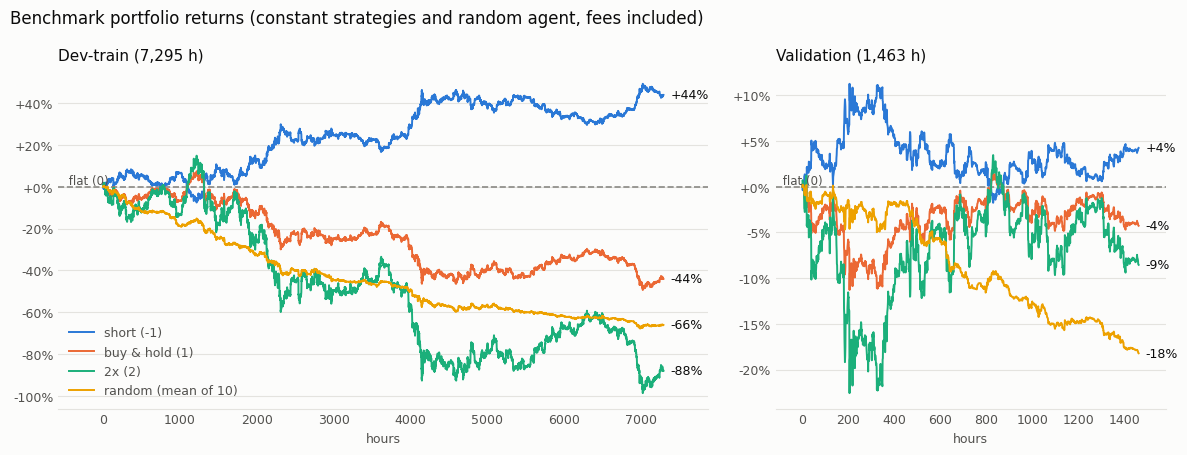

In [17]:
curves = {}
for split_name, split_env in [("dev_train", envs["dev_train"]), ("val", envs["val"])]:
    for name in ["always short (-1)", "buy and hold (1)", "always 2x (2)", "random"]:
        np.random.seed(0)
        _, episode_curves = evaluate(benchmarks[name](), split_env, num_episodes=10)
        curves[(split_name, name)] = np.mean(np.vstack(episode_curves), axis=0) - 1

labels = {"always short (-1)": "short (-1)", "buy and hold (1)": "buy & hold (1)",
          "always 2x (2)": "2x (2)", "random": "random (mean of 10)"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), facecolor=SURF, gridspec_kw=dict(width_ratios=[5, 3]))
for ax, split_name, title in [(axes[0], "dev_train", "Dev-train (7,295 h)"), (axes[1], "val", "Validation (1,463 h)")]:
    style_axis(ax, title)
    ax.axhline(0, color=NEUTRAL, lw=1.2, ls="--")
    ax.text(0.01, 0.0, " flat (0)", transform=ax.get_yaxis_transform(), va="bottom", fontsize=8.5, color=INK2)
    for color, (name, label) in zip(SERIES, labels.items()):
        eq = curves[(split_name, name)]
        ax.plot(eq * 100, color=color, lw=1.4, label=label)
        ax.annotate(f"{eq[-1]:+.0%}", (len(eq) - 1, eq[-1] * 100), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=9, color=INK)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.set_xlabel("hours", color=INK2, fontsize=9)
    ax.margins(x=0.08)
axes[0].legend(frameon=False, fontsize=9, loc="lower left", labelcolor=INK2)
fig.suptitle("Benchmark portfolio returns (constant strategies and random agent, fees included)",
             x=0.01, ha="left", color=INK, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase1_benchmarks.png", dpi=150, facecolor=SURF)
plt.show()

### How much can luck move a result?

The same random agent with different seeds, 10 episodes each on the first validation window. The fees are the same every time; the result is not.

In [18]:
luck = []
for seed in range(5):
    summary, _ = validate(RandomAgent(len(POSITIONS), seed=seed), {"val_w1": val_envs["val_w1"]})
    luck.append({"agent seed": seed, "mean return": f"{summary.loc['val_w1', 'portfolio_return']:+.2%}",
                 "std over episodes": f"{summary.loc['val_w1', 'portfolio_return_std']:.2%}",
                 "fees": f"{summary.loc['val_w1', 'fees_approx']:.2%}"})
pd.DataFrame(luck).set_index("agent seed")

,mean return,std over episodes,fees
agent seed,,,
0,-11.44%,8.41%,8.44%
1,-6.13%,16.84%,8.51%
2,-1.12%,9.10%,8.24%
3,-7.28%,9.91%,8.40%
4,-9.40%,12.18%,8.52%


## Takeaways

- **Always short wins both splits** because both periods fall. It is a bet on the direction of the market, not a strategy, and it is exactly what a bear-market training set invites an agent to learn.
- **Random loses mainly through fees** (about 8.4% per eval-length episode), and its result swings by several percent from seed to seed. A single run proves nothing.
- **Leverage multiplies drawdowns**: holding 2x through dev-train ends at -88%.

**Success bars for my agent on validation** (at least 3 seeds):
1. Positive return after fees (beats flat and random).
2. Positive excess return over buy and hold.
3. Beat always short (+4.24% on the full validation period), or reach a similar return with a policy whose position shares show that it actually reacts to the market.